In [1]:
import os
import numpy as np
import glob
from PIL import Image, ImageDraw

# pip install torchsummary
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
import torch.optim as optim
from time import time

import matplotlib.pyplot as plt
from IPython.display import clear_output
import random
from scipy.ndimage import measurements
from skimage import measure
from scipy.ndimage import distance_transform_edt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
import sys
sys.path.append('/zhome/a4/f/202251/projects/02516-IDLCV/exe/exe2/')
# from click_generator import generate_clicks
import random
from scipy.ndimage import center_of_mass, label
from skimage import measure
from scipy.ndimage import distance_transform_edt
import numpy as np

def generate_clicks(mask, num_pos_clicks=2, num_neg_clicks=2, include_background_clicks=True, sampling_strategy='centroid'):
    pos_clicks = []
    neg_clicks = []

    if sampling_strategy == 'centroid':
        centroid_list = centroid_points(mask)
        if len(centroid_list) == 0:
            return np.array(pos_clicks)
        while len(pos_clicks) < num_pos_clicks:
            for c_x, c_y in centroid_list:
                if len(pos_clicks) < num_pos_clicks:
                    pos_clicks.append([c_x, c_y])
                else:
                    break
            if len(pos_clicks) < num_pos_clicks:
                for c_x, c_y in centroid_list:
                    x_click, y_click = add_random_offset(c_x, c_y, mask.shape)
                    pos_clicks.append([x_click, y_click])
                    if len(pos_clicks) >= num_pos_clicks:
                        break
    elif sampling_strategy == 'random':
        pos_clicks += random_points_within_object(mask, num_pos_clicks)
    elif sampling_strategy == 'boundary':
        pos_clicks += boundary_points(mask, num_pos_clicks)
    else:
        raise ValueError("Invalid sampling strategy")

    # Background clicks
    if include_background_clicks:
        neg_clicks += random_points_in_background(mask, num_neg_clicks, min_distance=5)

    return np.array(pos_clicks), np.array(neg_clicks)

def add_random_offset(c_x, c_y, shape, offset_range=5):
    x_offset = random.randint(-offset_range, offset_range)
    y_offset = random.randint(-offset_range, offset_range)
    x_click = c_x + x_offset
    y_click = c_y + y_offset
    # Ensure the click is within the image bounds
    height, width = shape
    x_click = min(max(x_click, 0), width - 1)
    y_click = min(max(y_click, 0), height - 1)
    return x_click, y_click

def centroid_points(mask):
    mask_binary = mask > 0.5
    labeled_mask, num_features = label(mask_binary)
    centroids = []
    for region_label in range(1, num_features + 1):
        region = (labeled_mask == region_label)
        if np.sum(region) == 0:
            continue
        c_y, c_x = center_of_mass(region)
        centroids.append((int(c_x), int(c_y)))
    return centroids

def random_points_within_object(mask, num_clicks):
    y_coords, x_coords = np.where(mask > 0.5)
    if len(x_coords) == 0:
        return []  # No foreground pixels found
    # Create a list of indices and shuffle them
    indices = list(range(len(x_coords)))
    random.shuffle(indices)
    selected_clicks = []
    for idx in indices[:num_clicks]:
        selected_clicks.append([x_coords[idx], y_coords[idx]])
    return selected_clicks

def boundary_points(mask, num_clicks):
    contours = measure.find_contours(mask, level=0.5)
    if not contours:
        return []  # No contours found
    boundary = np.vstack(contours)
    num_boundary_points = len(boundary)
    if num_boundary_points == 0:
        return []
    # Create a list of indices and shuffle them
    indices = list(range(num_boundary_points))
    random.shuffle(indices)
    selected_clicks = []
    for idx in indices[:num_clicks]:
        y, x = boundary[idx]
        selected_clicks.append([int(x), int(y)])
    return selected_clicks

def random_points_in_background(mask, num_clicks, min_distance=5):
    background_mask = (mask <= 0.5).astype(np.uint8)
    distance_map = distance_transform_edt(background_mask)
    far_background_mask = (distance_map >= min_distance)
    y_coords, x_coords = np.where(far_background_mask)
    if len(x_coords) == 0:
        return []  # No suitable background pixels found
    # Create a list of indices and shuffle them
    indices = list(range(len(x_coords)))
    random.shuffle(indices)
    selected_clicks = []
    for idx in indices[:num_clicks]:
        selected_clicks.append([x_coords[idx], y_coords[idx]])
    return selected_clicks

def Dice(y_pred, y_true, smooth=1e-6):
    intersection = np.sum(y_pred & y_true)
    sum_pred = np.sum(y_pred)
    sum_true = np.sum(y_true)
    return (2. * intersection) / (sum_pred + sum_true + smooth)

def IoU(y_pred, y_true, smooth=1e-6):
    intersection = np.sum(y_pred & y_true)
    union = np.sum(y_pred) + np.sum(y_true) - intersection
    return (intersection) / (union + smooth)

def Sensitivity(y_pred, y_true, smooth=1e-6):
    TP = (y_pred & y_true).sum()
    FN = ((~y_pred) & y_true).sum()
    return (TP) / (TP + FN + smooth)

def Specificity(y_pred, y_true, smooth=1e-6):
    TN = ((~y_pred) & (~y_true)).sum()
    FP = (y_pred & (~y_true)).sum()
    return (TN) / (TN + FP + smooth)

def Precision(y_pred, y_true, smooth=1e-6):
    TP = np.sum(y_pred & y_true)
    FP = np.sum(y_pred & (~y_true))
    return TP / (TP + FP + smooth)

In [3]:
data_path = '/dtu/datasets1/02516/PH2_Dataset_images/'

class PhC(torch.utils.data.Dataset):
    def __init__(self, is_train, transform,
                 data_path=data_path, sampling_strategy='centroid',
                 num_pos_clicks=2, num_neg_clicks=2, include_background_clicks=True):
        self.transform = transform
        self.sampling_strategy = sampling_strategy
        self.num_pos_clicks = num_pos_clicks
        self.num_neg_clicks = num_neg_clicks
        self.include_background_clicks = include_background_clicks

        image_paths = sorted(glob.glob(data_path + '/*/*_Dermoscopic_Image/*.bmp'))
        label_paths = sorted(glob.glob(data_path + '/*/*_lesion/*.bmp'))
        idx = int(len(image_paths) * 0.8)
        self.image_paths = image_paths[:idx] if is_train else image_paths[idx:]
        self.label_paths = label_paths[:idx] if is_train else label_paths[idx:]

    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]

        image = Image.open(image_path)
        label = Image.open(label_path).convert('L')
        # Apply transformations
        Y = self.transform(label)
        X = self.transform(image)

        pos_clicks, neg_clicks = generate_clicks(Y.squeeze().numpy(),
                                                 num_pos_clicks=self.num_pos_clicks,
                                                 num_neg_clicks=self.num_neg_clicks,
                                                 sampling_strategy=self.sampling_strategy,
                                                 include_background_clicks=self.include_background_clicks)

        pos_labels = np.ones(len(pos_clicks), dtype=int)
        neg_labels = np.zeros(len(neg_clicks), dtype=int)

        clicks = np.concatenate((pos_clicks, neg_clicks), axis=0)
        labels = np.concatenate((pos_labels, neg_labels), axis=0)

        return X, Y, clicks, labels


size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.ToTensor()])

batch_size = 6
trainset = PhC(is_train=True, transform=train_transform)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)

print('Loaded %d training images' % len(trainset))
print('Loaded %d test images' % len(testset))

Loaded 160 training images
Loaded 40 test images


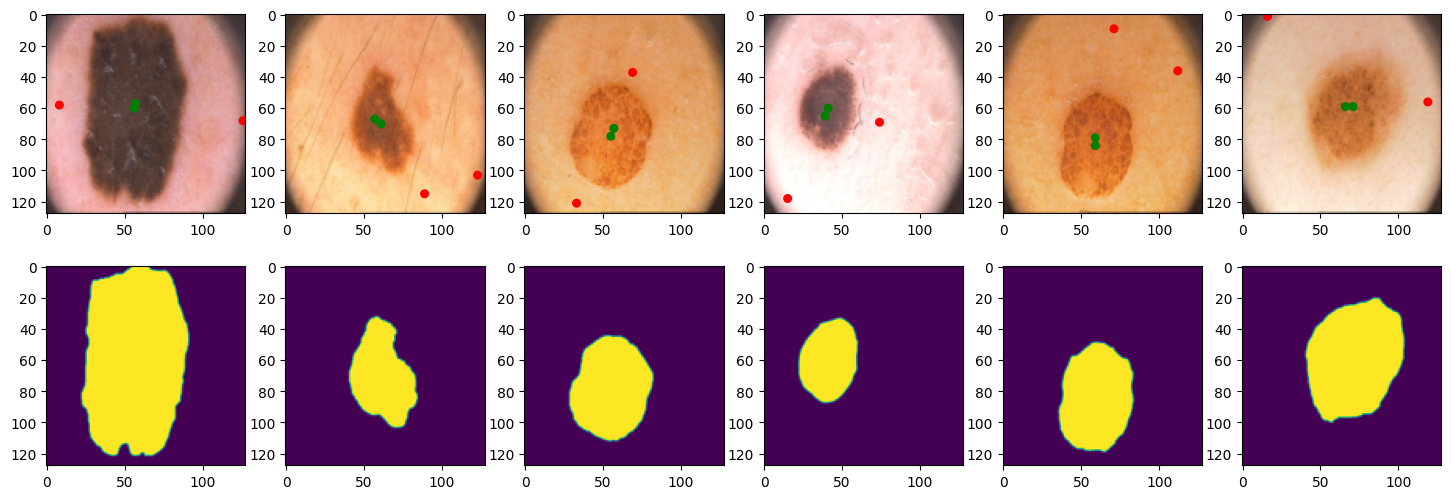

In [4]:
plt.rcParams['figure.figsize'] = [18, 6]

images, labels, clicks, click_labels = next(iter(train_loader))

for i in range(6):
    plt.subplot(2, 6, i+1)
    click = clicks[i].cpu().numpy()
    labels_i = click_labels[i].cpu().numpy()

    colors = ['green' if label == 1 else 'red' for label in labels_i]
    plt.scatter(click[:, 0], click[:, 1], c=colors, s=30 )
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))
    plt.subplot(2, 6, i+7)
    plt.imshow(labels[i].squeeze())
plt.show()

In [5]:
bce_loss = nn.BCEWithLogitsLoss()

def image_level_loss(S, L):
  batch_size = S.size(0)
  losses = []

  for i in range(batch_size):
    Si = S[i].squeeze()
    present_classes = np.unique(L[i])
    img_loss = 0.0
    Si_flat = Si.view(-1)
    for c in present_classes:
      if c == 1:
          max_s, _ = torch.max(Si_flat, dim=0)
          img_loss += -torch.log(max_s + 1e-6)
      else:
          min_s, _ = torch.min(Si_flat, dim=0)
          img_loss += -torch.log(1 - min_s + 1e-6) # 对于背景, 1-最小的概率值,就是背景的最大概率
    img_loss = img_loss / len(present_classes)
    losses.append(img_loss)
  return torch.stack(losses).mean()

def point_level_loss(S, clicks, click_labels, alpha=1.0):
  batch_size = S.size(0)
  loss = 0.0

  for i in range(batch_size):
    curr_clicks = clicks[i]
    labels = click_labels[i]
    for j in range(len(curr_clicks)):
      x, y = curr_clicks[j]
      label = labels[j]
      Si = S[i, 0, y, x]
      if label == 1:
          loss += alpha * torch.log(Si + 1e-8)
      else:
          loss += alpha * torch.log(1 - Si + 1e-8)
    return loss / batch_size

def total_loss(Y_pred, clicks, click_labels, alpha=1.0):
  S = torch.sigmoid(Y_pred)
  p_loss = point_level_loss(S, clicks, click_labels, alpha)
  img_loss = image_level_loss(S, click_labels)
  return img_loss - p_loss

In [6]:
def train(model, opt, loss_fn, epochs, train_loader, test_loader):
    X_test, Y_test, clicks_test, click_labels_test = next(iter(test_loader))

    for epoch in range(epochs):
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        model.train()  # train mode
        for X_batch, Y_batch, clicks, label in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            # set parameter gradients to zero
            opt.zero_grad()

            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_pred, clicks, label)  # forward-pass
            loss.backward()  # backward-pass
            opt.step()  # update weights

            # calculate metrics to show the user
            avg_loss += loss / len(train_loader)
        toc = time()
        print(' - loss: %f' % avg_loss)

        # show intermediate results
        model.eval()  # testing mode
        Y_hat = F.sigmoid(model(X_test.to(device))).detach().cpu()
        clear_output(wait=True)
        fig, axes = plt.subplots(3, 4, figsize=(15, 10))
        for k in range(4):
            click = clicks_test[k]
            labels_i = click_labels_test[i].cpu().numpy()

            colors = ['green' if label == 1 else 'red' for label in labels_i]
            axes[0, k].scatter(click[:, 0], click[:, 1], c=colors, s=30 )
            axes[0, k].imshow(np.rollaxis(X_test[k].numpy(), 0, 3), cmap='gray')
            axes[0, k].set_title('Real')
            axes[0, k].axis('off')
            axes[1, k].imshow(Y_test[k, 0], cmap='gray')
            # axes[1, k].scatter(click.T[0],click.T[1], c='red', s=10)
            axes[1, k].set_title('Truth')
            axes[1, k].axis('off')

            axes[2, k].imshow(Y_hat[k, 0], cmap='gray')
            axes[2, k].set_title('Output')
            axes[2, k].axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()

In [7]:
def evaluate(model, data_loader):
  model.eval()
  total_dice, total_iou, total_sensitivity, total_specificity, total_precision = 0, 0, 0, 0, 0
  num_samples = 0
  with torch.no_grad():
      for batch in data_loader:
          X_batch, Y_batch, clicks_list, labels_list,  = batch
          X_batch = X_batch.to(device)  # [batch_size, C, H, W]
          Y_batch = Y_batch.to(device)  # [batch_size, 1, H, W]

          outputs = torch.sigmoid(model(X_batch)).cpu().numpy()  # [batch_size, 1, H, W]

          Y_pred = (outputs > 0.5).astype(bool).reshape(outputs.shape[0], -1)  # [batch_size, H*W]
          Y_true = (Y_batch.cpu().numpy() > 0.5).astype(bool).reshape(Y_batch.shape[0], -1)  # [batch_size, H*W]

          # 遍历批次中的每个样本，计算指标
          for i in range(Y_pred.shape[0]):
              y_p = Y_pred[i]
              y_t = Y_true[i]
              dice_score = Dice(y_p, y_t)
              iou_score = IoU(y_p, y_t)
              sensitivity_score = Sensitivity(y_p, y_t)
              specificity_score = Specificity(y_p, y_t)
              precision_score = Precision(y_p, y_t)

              total_dice += dice_score
              total_iou += iou_score
              total_sensitivity += sensitivity_score
              total_specificity += specificity_score
              total_precision += precision_score
              num_samples += 1

  # 计算所有样本的平均指标
  avg_dice = total_dice / num_samples
  avg_iou = total_iou / num_samples
  avg_sensitivity = total_sensitivity / num_samples
  avg_specificity = total_specificity / num_samples
  avg_precision = total_precision / num_samples

  # 打印评估结果
  print(f"Dice: {avg_dice:.4f}, IoU: {avg_iou:.4f}, Sensitivity: {avg_sensitivity:.4f}, Specificity: {avg_specificity:.4f}, Precision: {avg_precision:.4f}")

  # 返回评估指标
  return {
      'Dice': avg_dice,
      'IoU': avg_iou,
      'Sensitivity': avg_sensitivity,
      'Specificity': avg_specificity,
      'Precision': avg_precision
  }


In [8]:
class UNet_BN(nn.Module):
    def __init__(self):
        super().__init__()
        # 编码器（下采样）
        self.enc_conv0 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn_enc0 = nn.BatchNorm2d(64)
        self.pool0 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 128 -> 64

        self.enc_conv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_enc1 = nn.BatchNorm2d(64)
        self.pool1 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 64 -> 32

        self.enc_conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_enc2 = nn.BatchNorm2d(64)
        self.pool2 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 32 -> 16

        self.enc_conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_enc3 = nn.BatchNorm2d(64)
        self.pool3 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 16 -> 8

        # Bottleneck
        self.bottleneck_conv = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_bottleneck = nn.BatchNorm2d(64)

        # 解码器（上采样）
        self.upsample0 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 8 -> 16
        self.dec_conv0 = nn.Conv2d(64 + 64, 64, 3, padding=1)
        self.bn_dec0 = nn.BatchNorm2d(64)

        self.upsample1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 16 -> 32
        self.dec_conv1 = nn.Conv2d(64 + 64, 64, 3, padding=1)
        self.bn_dec1 = nn.BatchNorm2d(64)

        self.upsample2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 32 -> 64
        self.dec_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)
        self.bn_dec2 = nn.BatchNorm2d(64)

        self.upsample3 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 64 -> 128
        self.dec_conv3 = nn.Conv2d(64 + 64, 1, 3, padding=1)

    def forward(self, x):
        # 编码器
        e0 = F.relu(self.bn_enc0(self.enc_conv0(x)))
        e0p = self.pool0(e0)

        e1 = F.relu(self.bn_enc1(self.enc_conv1(e0p)))
        e1p = self.pool1(e1)

        e2 = F.relu(self.bn_enc2(self.enc_conv2(e1p)))
        e2p = self.pool2(e2)

        e3 = F.relu(self.bn_enc3(self.enc_conv3(e2p)))
        e3p = self.pool3(e3)

        # Bottleneck
        b = F.relu(self.bn_bottleneck(self.bottleneck_conv(e3p)))

        # 解码器
        d0 = F.relu(self.bn_dec0(self.dec_conv0(torch.cat([self.upsample0(b), e3], dim=1))))

        d1 = F.relu(self.bn_dec1(self.dec_conv1(torch.cat([self.upsample1(d0), e2], dim=1))))

        d2 = F.relu(self.bn_dec2(self.dec_conv2(torch.cat([self.upsample2(d1), e1], dim=1))))
        d3 = self.dec_conv3(torch.cat([self.upsample3(d2), e0], dim=1))

        output = torch.sigmoid(d3)
        return output

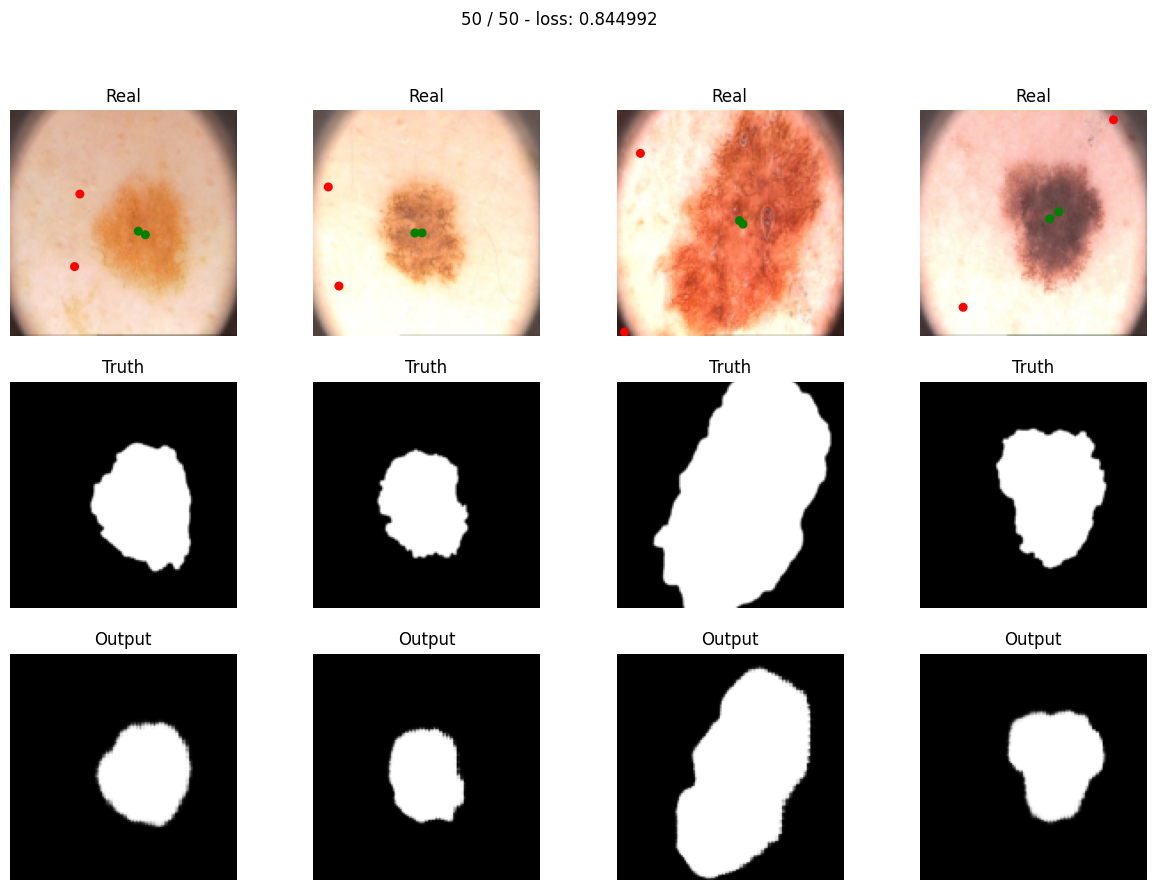

Dice: 0.6537, IoU: 0.5353, Sensitivity: 0.9966, Specificity: 0.1275, Precision: 0.5378


{'Dice': 0.6537035521475676,
 'IoU': 0.5352794978728279,
 'Sensitivity': 0.996571572385753,
 'Specificity': 0.12751155093463187,
 'Precision': 0.5378351611160327}

In [9]:
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

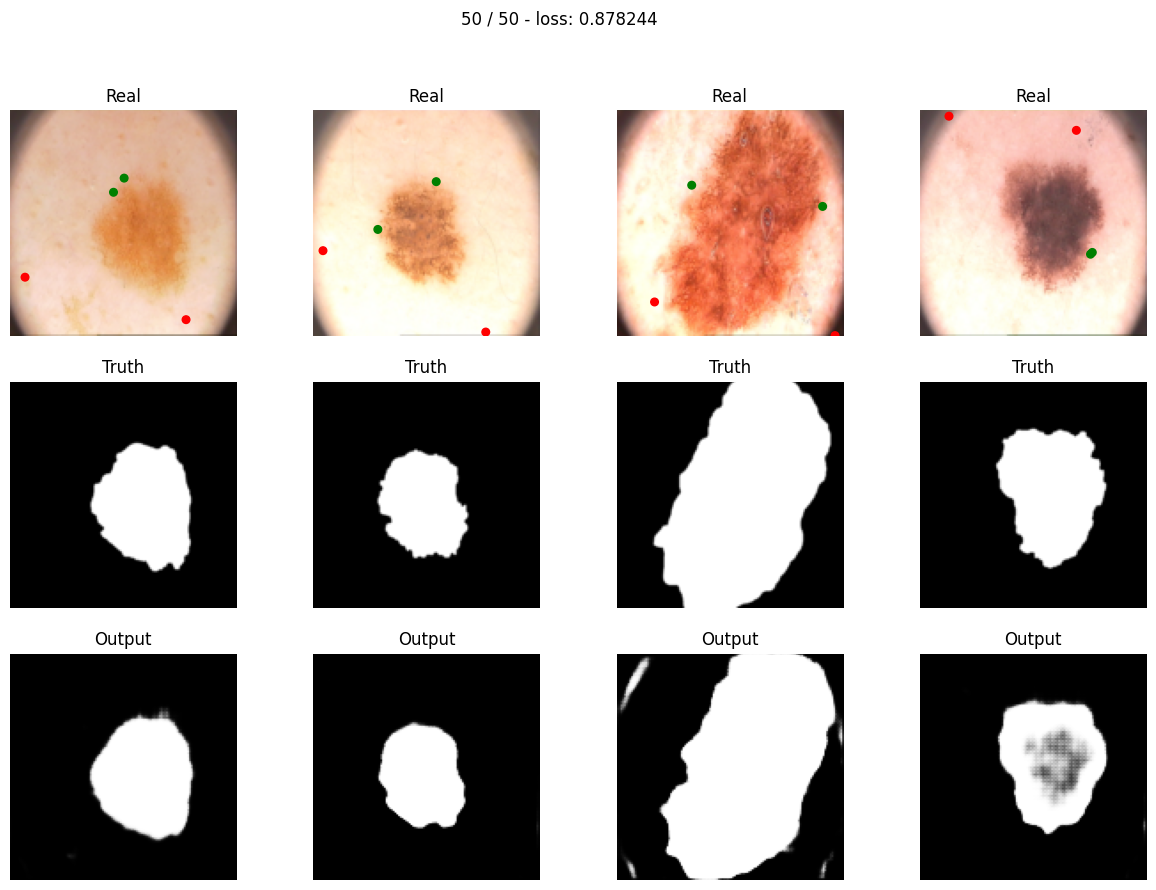

Dice: 0.6532, IoU: 0.5276, Sensitivity: 0.9685, Specificity: 0.2129, Precision: 0.5502


{'Dice': 0.6531593846537748,
 'IoU': 0.5275831565152097,
 'Sensitivity': 0.9684843573650633,
 'Specificity': 0.2129119794255406,
 'Precision': 0.550245049267766}

In [10]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='boundary',)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='boundary',)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

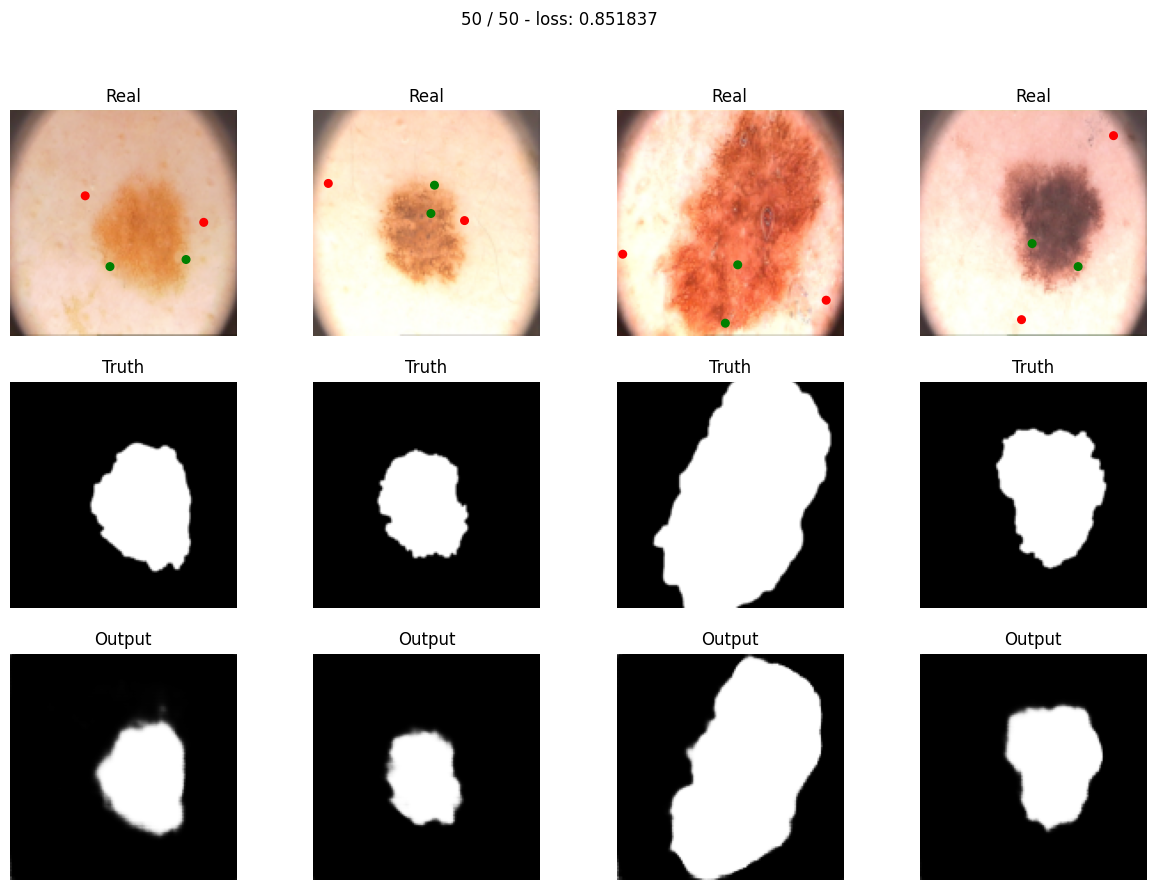

Dice: 0.6982, IoU: 0.5793, Sensitivity: 0.9669, Specificity: 0.4109, Precision: 0.6054


{'Dice': 0.698151896142879,
 'IoU': 0.5793073023134604,
 'Sensitivity': 0.9669357752364363,
 'Specificity': 0.4109179429134904,
 'Precision': 0.6054198612332337}

In [11]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='random',)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='random',)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

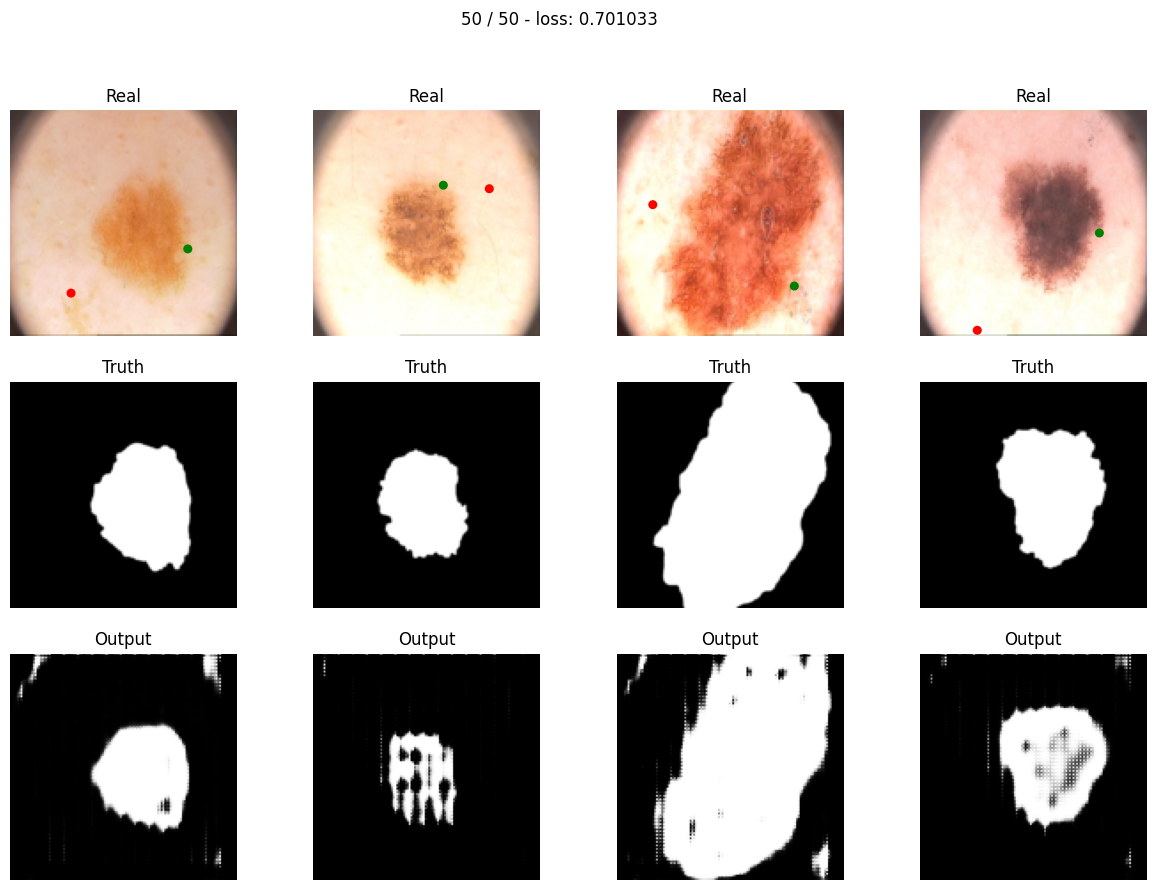

Dice: 0.6460, IoU: 0.5232, Sensitivity: 0.9858, Specificity: 0.1515, Precision: 0.5331


{'Dice': 0.6460424049024733,
 'IoU': 0.5231576963156412,
 'Sensitivity': 0.9858086946178473,
 'Specificity': 0.15153182028753043,
 'Precision': 0.5330934323163952}

In [12]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='boundary', num_pos_clicks=1, num_neg_clicks=1)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='boundary', num_pos_clicks=1, num_neg_clicks=1)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

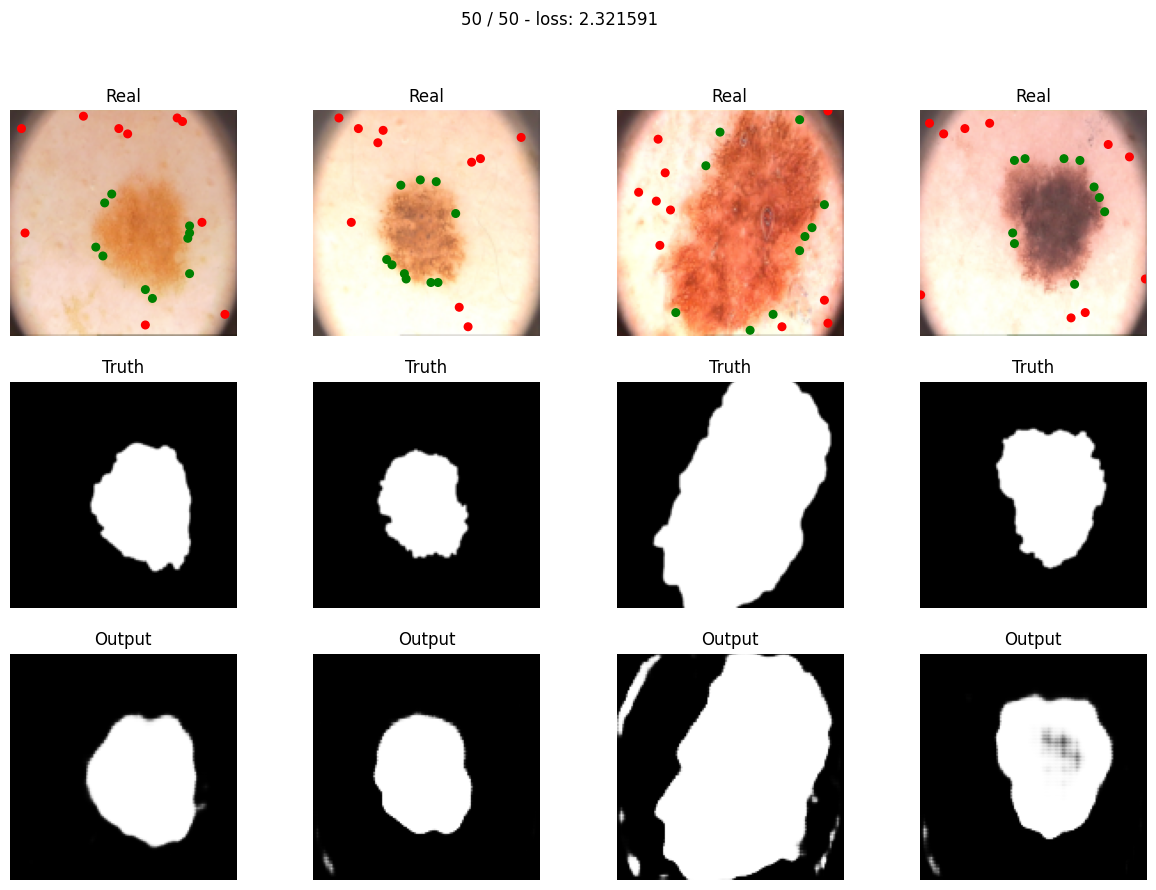

Dice: 0.6625, IoU: 0.5231, Sensitivity: 0.9237, Specificity: 0.3327, Precision: 0.5721


{'Dice': 0.662493145374674,
 'IoU': 0.5230741933352998,
 'Sensitivity': 0.9237113245703256,
 'Specificity': 0.3327478558705885,
 'Precision': 0.5720777345187626}

In [13]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='boundary', num_pos_clicks=10, num_neg_clicks=10)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='boundary', num_pos_clicks=10, num_neg_clicks=10)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

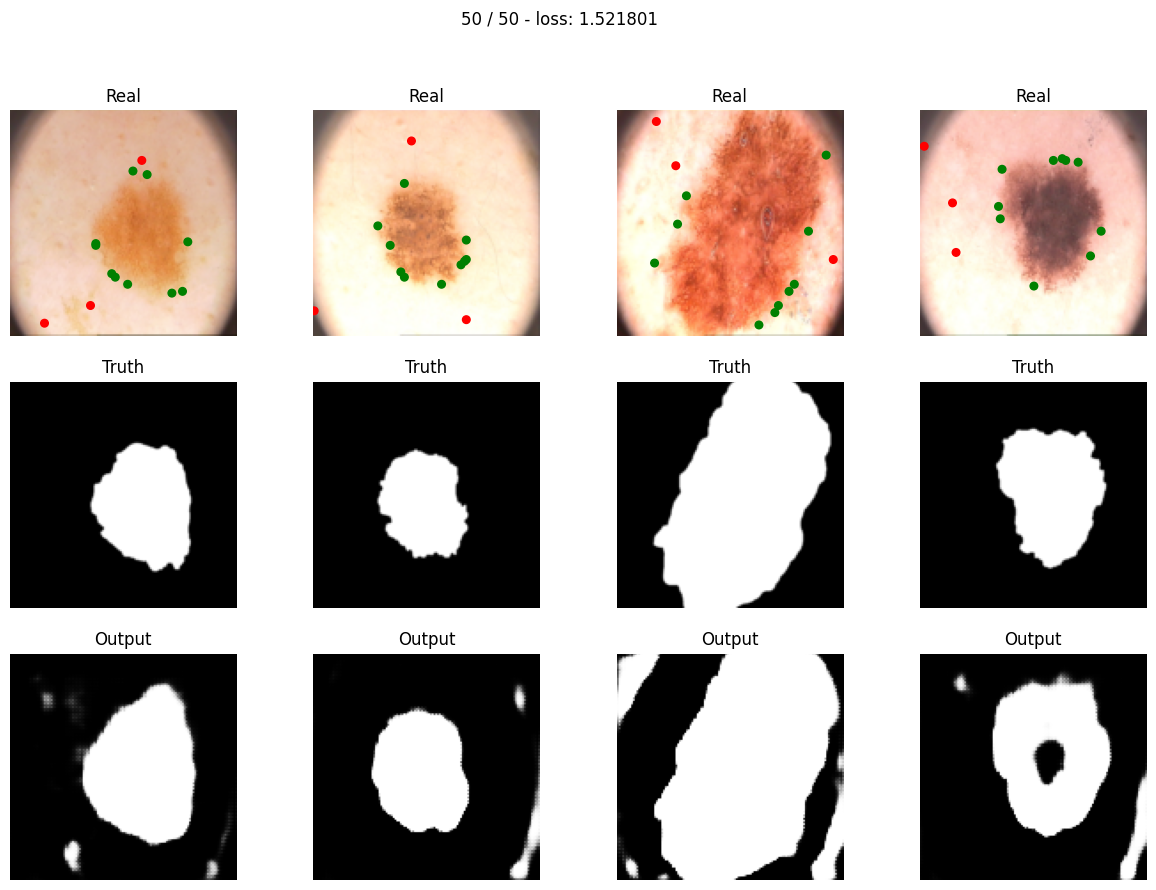

Dice: 0.6461, IoU: 0.5245, Sensitivity: 0.9930, Specificity: 0.1198, Precision: 0.5292


{'Dice': 0.6460721799467285,
 'IoU': 0.5245428771125376,
 'Sensitivity': 0.9930006707852256,
 'Specificity': 0.11976387936140123,
 'Precision': 0.5291860020675712}

In [14]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='boundary', num_pos_clicks=10, num_neg_clicks=3)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='boundary', num_pos_clicks=10, num_neg_clicks=3)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

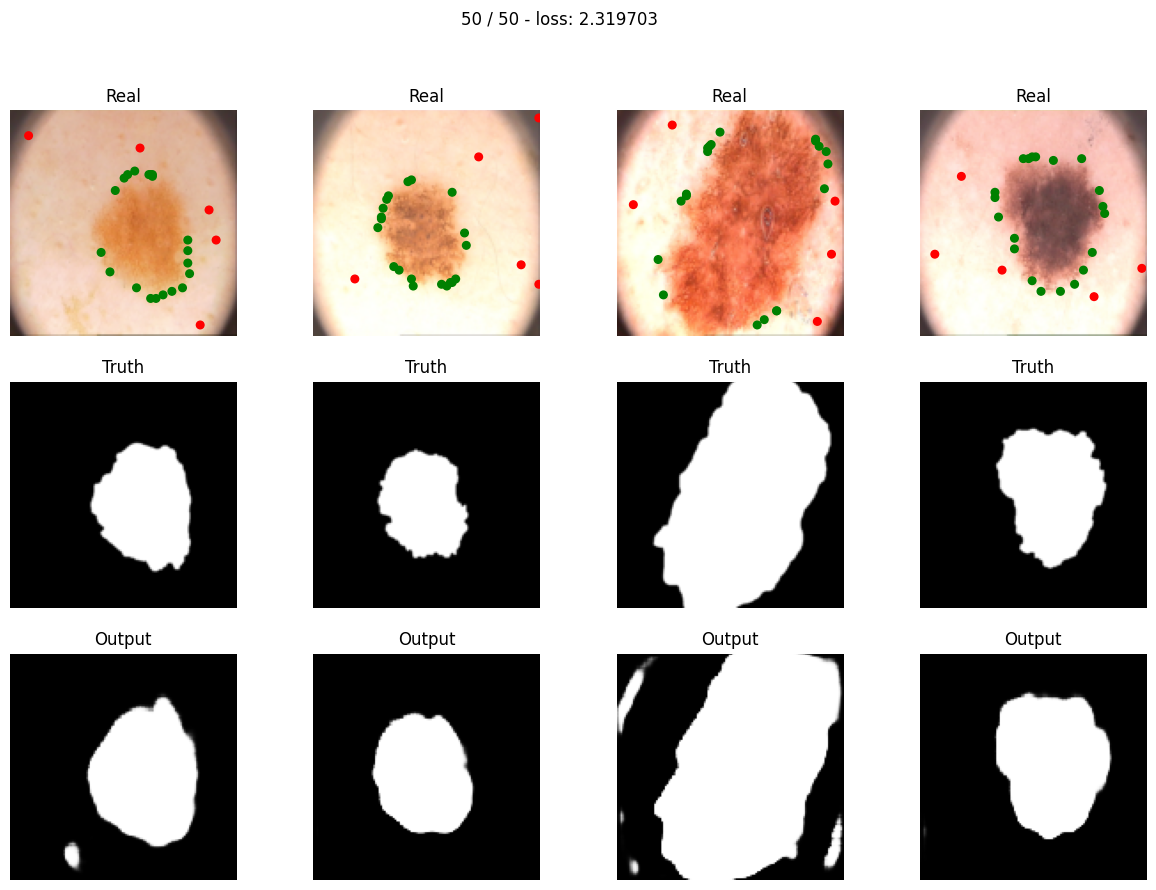

Dice: 0.6661, IoU: 0.5440, Sensitivity: 0.9876, Specificity: 0.2072, Precision: 0.5529


{'Dice': 0.6660968517006997,
 'IoU': 0.5440291926518392,
 'Sensitivity': 0.9876305946213725,
 'Specificity': 0.2072437304027,
 'Precision': 0.5528596142448816}

In [15]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='boundary', num_pos_clicks=20, num_neg_clicks=5)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='boundary', num_pos_clicks=20, num_neg_clicks=5)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

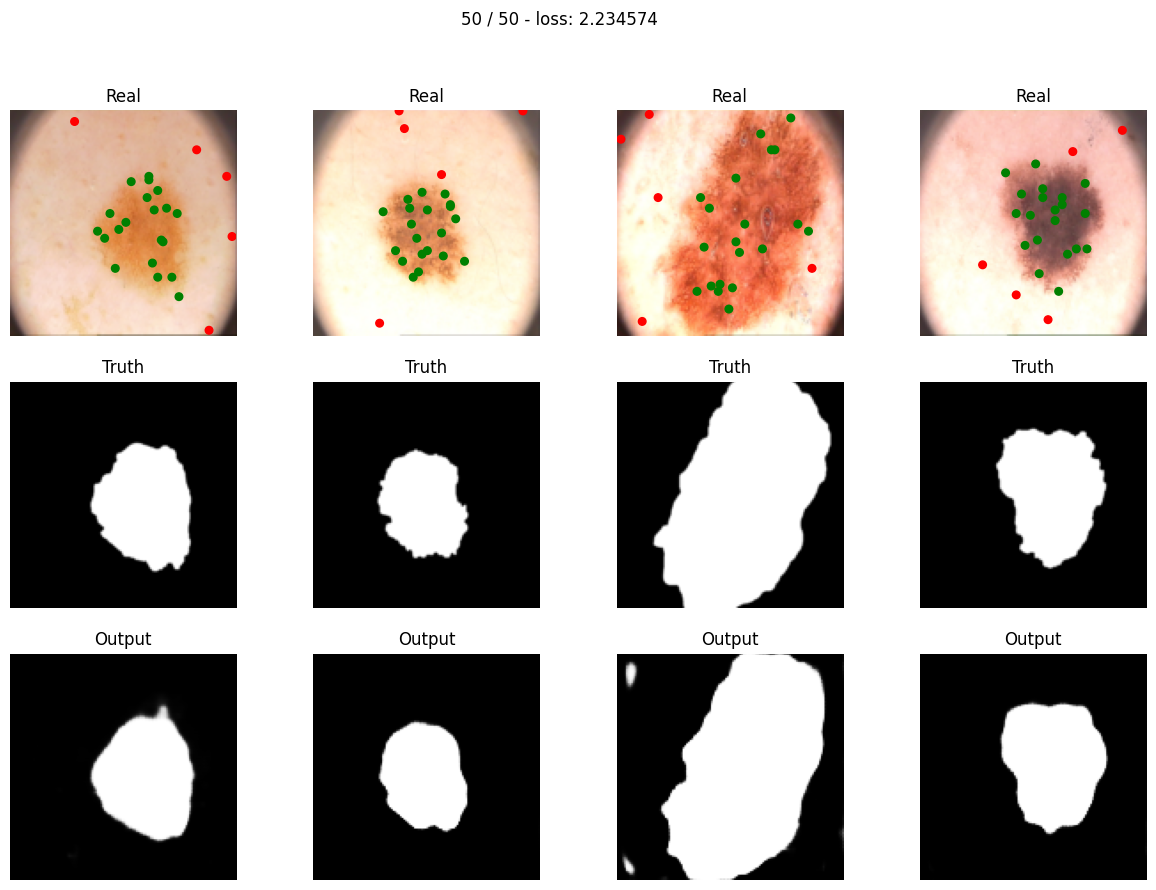

Dice: 0.6571, IoU: 0.5303, Sensitivity: 0.9814, Specificity: 0.2008, Precision: 0.5444


{'Dice': 0.6570629675616261,
 'IoU': 0.5303053520142513,
 'Sensitivity': 0.9813889381963238,
 'Specificity': 0.20078659106093225,
 'Precision': 0.544447412351907}

In [16]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='random', num_pos_clicks=20, num_neg_clicks=5)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='random', num_pos_clicks=20, num_neg_clicks=5)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)

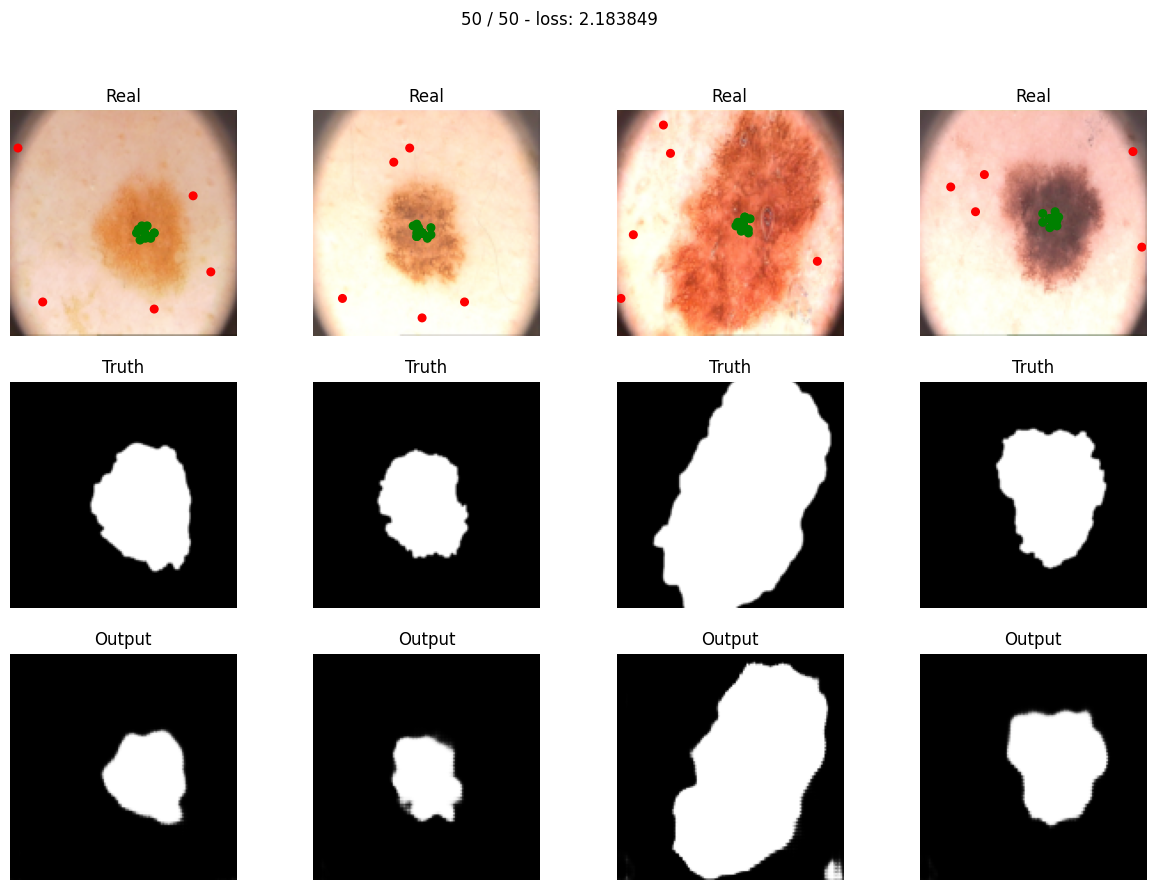

Dice: 0.6571, IoU: 0.5330, Sensitivity: 0.9798, Specificity: 0.2205, Precision: 0.5469


{'Dice': 0.6571176705952689,
 'IoU': 0.532964929752772,
 'Sensitivity': 0.9797533985068542,
 'Specificity': 0.22045005808532953,
 'Precision': 0.5468670650419419}

In [17]:
trainset = PhC(is_train=True, transform=train_transform, sampling_strategy='centroid', num_pos_clicks=20, num_neg_clicks=5)
train_loader = train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
testset = PhC(is_train=False, transform=test_transform, sampling_strategy='centroid', num_pos_clicks=20, num_neg_clicks=5)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), total_loss, 50, train_loader, test_loader)
evaluate(model_unet_bn, test_loader)